# Prediction - Inpatient Bed Utilization Above State Threshold

## Import Dependencies

In [1]:
from datetime import datetime
import lightgbm as lgb
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import ExponentialSmoothing, Holt
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

## Define Parameters

In [2]:
ANALYSIS_START = datetime(2021, 1, 1)
ANALYSIS_END = datetime(2024, 4, 27)
FEATURE_WINDOWS = [1, 2, 3] # units in days
STATE_PERCENTILE = 0.90 # percentile threshold for `inpatient_beds_utilization`
DAYS_AHEAD = 5 # number of days to predict ahead
FOLDS= 5
MISSINGNESS_PROP = 0.20
THRESHOLD_YEAR = 2020

## Load Data

In [3]:
df = pd.read_csv('data/covid_features_all_states_20200101_20251231.csv')

df.head()

,date,state,fb-survey_smoothed_wwearing_mask_7d,fb-survey_smoothed_wcovid_vaccinated_appointment_or_accept,google-symptoms_sum_anosmia_ageusia_smoothed_search,fb-survey_smoothed_wcli,fb-survey_smoothed_whh_cmnty_cli,doctor-visits_smoothed_adj_cli,jhu-csse_confirmed_incidence_num,hhs_confirmed_admissions_covid_1d_prop_7dav,...,inpatient_beds_utilization,percent_of_inpatients_with_covid,inpatient_bed_covid_utilization,adult_icu_bed_covid_utilization,adult_icu_bed_utilization,cases_roll_7,day_of_year,day_of_week,month_of_year,quarter_of_year
0,2020-01-01,AK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1,2,1,1
1,2020-01-02,AK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2,3,1,1
2,2020-01-03,AK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3,4,1,1
3,2020-01-04,AK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4,5,1,1
4,2020-01-05,AK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5,6,1,1


## Data Preprocessing and Feature Engineering

In [4]:
# convert to datetime
df['date'] = pd.to_datetime(df['date'], format = '%Y-%m-%d')

# sor time series
df = df.sort_values(by=['state', 'date'])

# Need to use `pd.concat` to prevent fragmented dataframe
years = df['date'].dt.year.to_frame()
years.columns = ['year']
months = df['date'].dt.month.to_frame()
months.columns = ['month']
days = df['date'].dt.day_of_week.to_frame()
days.columns = ['dayofweek']
weeks = df['date'].dt.isocalendar().week.astype('int').to_frame()
weeks.columns = ['weekofyear']
df = pd.concat([df, years, months, days, weeks], axis=1)

df = df.set_index('date', drop=False)

df['date'].head()

date
2020-01-01   2020-01-01
2020-01-02   2020-01-02
2020-01-03   2020-01-03
2020-01-04   2020-01-04
2020-01-05   2020-01-05
Name: date, dtype: datetime64[us]

In [5]:
# Use 2020 data to get obtain state-specific threshold for `inpatient_beds_utilization`
means = df[df['date'].dt.year==THRESHOLD_YEAR].groupby('state').mean()

state_thresholds = df[df['date'].dt.year==THRESHOLD_YEAR][['inpatient_beds_utilization', 'state']].groupby('state').quantile(STATE_PERCENTILE)
state_thresholds.columns = ['state_thresholds']

df = pd.merge(left=df, right=state_thresholds, how = 'inner', left_on='state', right_on='state')

df[['inpatient_beds_utilization', 'state', 'state_thresholds']].head()

,inpatient_beds_utilization,state,state_thresholds
0,NaN,AK,0.630065
1,NaN,AK,0.630065
2,NaN,AK,0.630065
3,NaN,AK,0.630065
4,NaN,AK,0.630065


In [6]:
# Create Target Variable
df = df.copy()
df_grouped = df.groupby(['state'])['inpatient_beds_utilization'].shift(-1*DAYS_AHEAD)
df['target'] = (df_grouped > df['state_thresholds']).astype('int')

In [7]:
# Filter Data to Only Dates When `inpatient_beds_utilization` is measured
df = df[(df['date'] >= ANALYSIS_START) & (df['date'] <= ANALYSIS_END)].reset_index(drop=True)

<Axes: title={'center': 'Distribution at 90% Percentile'}, xlabel='target'>

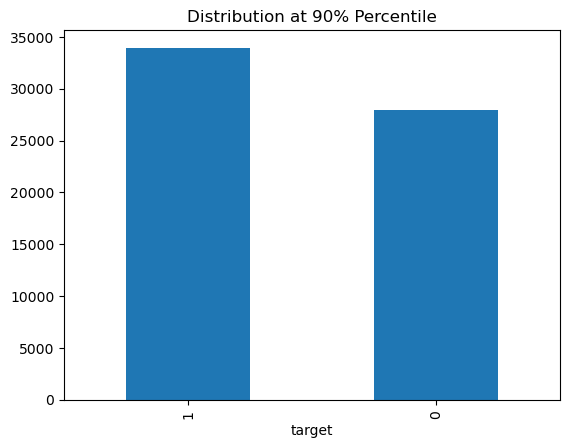

In [8]:
# Plot Target Variable
df['target'].value_counts().plot(kind='bar', title=f"Distribution at {int(100*STATE_PERCENTILE)}% Percentile")

Text(0.5, 1.0, 'Inpatient Capacity of VA Over Time')

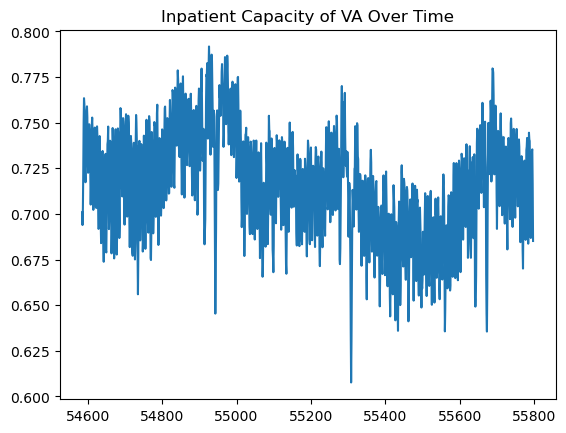

In [9]:
ex_state = 'VA' 
df_ex = df[df['state']==ex_state]
plt.plot(df_ex['inpatient_beds_utilization'])
plt.title(f"Inpatient Capacity of {ex_state} Over Time")

In [10]:
# Investigate Missing Values

missingness_pcts = df.isna().sum() / df.shape[0] 
features_to_drop = missingness_pcts[missingness_pcts > MISSINGNESS_PROP].index.to_list()

features_to_drop

['fb-survey_smoothed_wwearing_mask_7d',
 'fb-survey_smoothed_wcovid_vaccinated_appointment_or_accept',
 'google-symptoms_sum_anosmia_ageusia_smoothed_search',
 'fb-survey_smoothed_wcli',
 'fb-survey_smoothed_whh_cmnty_cli',
 'jhu-csse_confirmed_incidence_num',
 'jhu-csse_deaths_7dav_incidence_prop',
 'chng_7dav_inpatient_covid',
 'cases_roll_7']

In [11]:
# Drop Features with High Missingness

df = df.drop(columns=features_to_drop)

# Remaining Features
df.columns.sort_values().to_list()

['adult_icu_bed_covid_utilization',
 'adult_icu_bed_covid_utilization_coverage',
 'adult_icu_bed_covid_utilization_denominator',
 'adult_icu_bed_covid_utilization_numerator',
 'adult_icu_bed_utilization',
 'adult_icu_bed_utilization_coverage',
 'adult_icu_bed_utilization_denominator',
 'adult_icu_bed_utilization_numerator',
 'chng_smoothed_adj_outpatient_covid',
 'critical_staffing_shortage_anticipated_within_week_no',
 'critical_staffing_shortage_anticipated_within_week_not_reported',
 'critical_staffing_shortage_anticipated_within_week_yes',
 'critical_staffing_shortage_today_no',
 'critical_staffing_shortage_today_not_reported',
 'critical_staffing_shortage_today_yes',
 'date',
 'day_of_week',
 'day_of_year',
 'dayofweek',
 'deaths_covid',
 'deaths_covid_coverage',
 'doctor-visits_smoothed_adj_cli',
 'hhs_confirmed_admissions_covid_1d_prop_7dav',
 'hospital_onset_covid',
 'hospital_onset_covid_coverage',
 'icu_patients_confirmed_influenza',
 'icu_patients_confirmed_influenza_coverag

In [12]:
cols = [col for col in df.columns if col != 'state']

df[cols] = df[cols].fillna(df[cols].mean())

In [13]:
df.isna().sum().sum()

np.int64(0)

In [14]:
# IMPORTANT: Can't Use K-fold because it risks leaking future data into training and inference

X = df.drop(columns=['target'])

y = df['target']

tscv = TimeSeriesSplit(n_splits=FOLDS)

## Baseline Model

In [15]:
# Need to prove that our ML models beat basic heuristics

from sklearn.metrics import f1_score
import numpy as np

unique_dates = X.index.unique()

scores = []
for train_index, test_index in tscv.split(unique_dates):
    dates_train = unique_dates[train_index]
    dates_test = unique_dates[test_index]

    X_train = X[X.index.isin(dates_train)]
    y_train = y[y.index.isin(dates_train)]
    X_test = X[X.index.isin(dates_test)]
    y_test = y[y.index.isin(dates_test)]

    preds = (X_test['inpatient_beds_utilization'] > X_test['state_thresholds']).astype('int')

    scores.append(f1_score(y_test, preds))

results = np.mean(scores)

print(f"Baseline Results: {results:.3f}")

Baseline Results: 0.824


## ARIMA

In [16]:
import statsmodels

# Confirm data is stationary before running ARIMA model

statsmodels.tsa.stattools.adfuller(df_ex['inpatient_beds_utilization'])

(np.float64(-2.717605214901273),
 np.float64(0.07104102934761483),
 23,
 1189,
 {'1%': np.float64(-3.435861752677197),
  '5%': np.float64(-2.8639738850277796),
  '10%': np.float64(-2.568065847341873)},
 np.float64(-7643.975195837362))

In [17]:
scores = []
for train_index, test_index in tscv.split(unique_dates):
    dates_train = unique_dates[train_index]
    dates_test = unique_dates[test_index]

    X_train = X[X.index.isin(dates_train)]
    y_train = y[y.index.isin(dates_train)]
    X_test = X[X.index.isin(dates_test)]
    y_test = y[y.index.isin(dates_test)]


    for state in X_train['state'].unique():
        X_train_t = X_train[X_train['state']==state]['inpatient_beds_utilization']
        if len(X_train_t) < 30:
            continue
        mod = ARIMA(endog=X_train_t, order = (1,1,1))
        res = mod.fit()
        X_test_t = X_test[X_test['state']==state]
        y_test_t = y_test[X_test['state']==state]
        if len(y_test_t) < 30:
            continue
        forecast = res.forecast(steps=len(y_test_t))
        preds = (forecast > X_test_t['state_thresholds']).astype('int')

        scores.append(f1_score(y_test_t, preds))

results = np.mean(scores)

print(f"Baseline Results: {results:.3f}")

/Users/johnwhendricks/miniforge3/envs/ds5003/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/johnwhendricks/miniforge3/envs/ds5003/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/johnwhendricks/miniforge3/envs/ds5003/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/johnwhendricks/miniforge3/envs/ds5003/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters fou

Baseline Results: 0.648


## Exponential Smoothing

In [18]:
scores = []
for train_index, test_index in tscv.split(unique_dates):
    dates_train = unique_dates[train_index]
    dates_test = unique_dates[test_index]

    X_train = X[X.index.isin(dates_train)]
    y_train = y[y.index.isin(dates_train)]
    X_test = X[X.index.isin(dates_test)]
    y_test = y[y.index.isin(dates_test)]


    for state in X_train['state'].unique():
        X_train_t = X_train[X_train['state']==state]['inpatient_beds_utilization']
        if len(X_train_t) < 30:
            continue
        mod = ExponentialSmoothing(endog=X_train_t)
        res = mod.fit()
        X_test_t = X_test[X_test['state']==state]
        y_test_t = y_test[X_test['state']==state]
        if len(y_test_t) < 30:
            continue
        forecast = res.forecast(steps=len(y_test_t))
        preds = (forecast > X_test_t['state_thresholds']).astype('int')

        scores.append(f1_score(y_test_t, preds))

results = np.mean(scores)

print(f"Baseline Results: {results:.3f}")

Baseline Results: 0.648


## Holt Model

In [19]:
scores = []
for train_index, test_index in tscv.split(unique_dates):
    dates_train = unique_dates[train_index]
    dates_test = unique_dates[test_index]

    X_train = X[X.index.isin(dates_train)]
    y_train = y[y.index.isin(dates_train)]
    X_test = X[X.index.isin(dates_test)]
    y_test = y[y.index.isin(dates_test)]


    for state in X_train['state'].unique():
        X_train_t = X_train[X_train['state']==state]['inpatient_beds_utilization']
        if len(X_train_t) < 30:
            continue
        mod = Holt(endog=X_train_t)
        res = mod.fit()
        X_test_t = X_test[X_test['state']==state]
        y_test_t = y_test[X_test['state']==state]
        if len(y_test_t) < 30:
            continue
        forecast = res.forecast(steps=len(y_test_t))
        preds = (forecast > X_test_t['state_thresholds']).astype('int')

        scores.append(f1_score(y_test_t, preds))

results = np.mean(scores)

print(f"Baseline Results: {results:.3f}")

Baseline Results: 0.648


## Boosting

In [20]:
from sklearn.preprocessing import OneHotEncoder

X = df.drop(columns=['target'])

y = df['target']

X['dist'] = X['inpatient_beds_utilization'] - X['state_thresholds']

X['streak'] = ((
    X['dist'].shift(1) > 0) & (X['dist'].shift(2) > 0)
).astype('int')

FEATURES_TO_LAG = [
    'inpatient_beds_utilization', 'dist'
]

enc = OneHotEncoder(sparse_output=False)
enc.fit(X[['state']])
encoded_states = enc.transform(X[['state']])
state_cols = list(enc.get_feature_names_out(['state']))
df_states = pd.DataFrame(encoded_states, columns = state_cols)

X = pd.concat([X, df_states], axis=1).drop(columns=['date'])

X = X[
    ['inpatient_beds_utilization', 'state_thresholds', 
     'dist', 'month', 'year', 'dayofweek', 'weekofyear', 
     'state','staffed_adult_icu_bed_occupancy', 'streak', 'previous_day_deaths_covid_and_influenza'] + state_cols
]

for w in FEATURE_WINDOWS:
    for f in FEATURES_TO_LAG:
        X[f"{f}_{w}_day_lag"] = X.groupby(['state'], as_index=False).shift(w)[f]
        X[f"{f}_{w}_day_rolling"] = X.groupby(['state'], as_index=False).rolling(7*w).mean()[f]

scores = []
for train_index, test_index in tscv.split(unique_dates):
    dates_train = unique_dates[train_index]
    dates_test = unique_dates[test_index]

    X_train = X[X.index.isin(dates_train)]
    y_train = y[y.index.isin(dates_train)]
    X_test = X[X.index.isin(dates_test)]
    y_test = y[y.index.isin(dates_test)]

    X_train = X_train.drop(columns=['state'])
    
    X_test = X_test.drop(columns=['state'])

    mod = xgb.XGBRegressor(n_estimators = 300, max_depth = 5, learning_rate=0.05)

    mod.fit(X_train, y_train)

    forecast = mod.predict(X_test)

    preds = (forecast > X_test['state_thresholds']).astype('int')

    scores.append(f1_score(y_test, preds))

results = np.mean(scores)

print(f"XGBRegressor Results: {results:.3f}")

/var/folders/sx/dymxkj2j1636xvkc7jyhyp840000gn/T/ipykernel_93341/1230989245.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['dist'] = X['inpatient_beds_utilization'] - X['state_thresholds']
/var/folders/sx/dymxkj2j1636xvkc7jyhyp840000gn/T/ipykernel_93341/1230989245.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['streak'] = ((


XGBRegressor Results: 0.901


In [21]:
X = df.drop(columns=['target'])

y = df['target']

from sklearn.preprocessing import OneHotEncoder

X['dist'] = X['inpatient_beds_utilization'] - X['state_thresholds']

X['streak'] = ((
    X['dist'].shift(1) > 0) & (X['dist'].shift(2) > 0) & 
    (X['dist'].shift(3) > 0) & (X['dist'].shift(4) > 0) & 
    (X['dist'].shift(5) > 0)
).astype('int')

FEATURES_TO_LAG = [
    'inpatient_beds_utilization', 'dist', 'staffed_adult_icu_bed_occupancy'
]

enc = OneHotEncoder(sparse_output=False)
enc.fit(X[['state']])
encoded_states = enc.transform(X[['state']])
state_cols = list(enc.get_feature_names_out(['state']))
df_states = pd.DataFrame(encoded_states, columns = state_cols)

X = pd.concat([X, df_states], axis=1).drop(columns=['date'])

X = X[
    ['inpatient_beds_utilization', 'state_thresholds', 
     'dist', 'month', 'year', 'dayofweek', 'weekofyear', 
     'state','staffed_adult_icu_bed_occupancy', 'streak', 'previous_day_deaths_covid_and_influenza'] + state_cols
]

for w in FEATURE_WINDOWS:
    for f in FEATURES_TO_LAG:
        X[f"{f}_{w}_day_lag"] = X.groupby(['state'], as_index=False).shift(w)[f]
        X[f"{f}_{w}_day_rolling"] = X.groupby(['state'], as_index=False).rolling(7*w).mean()[f]

scores = []
for train_index, test_index in tscv.split(unique_dates):
    dates_train = unique_dates[train_index]
    dates_test = unique_dates[test_index]

    X_train = X[X.index.isin(dates_train)]
    y_train = y[y.index.isin(dates_train)]
    X_test = X[X.index.isin(dates_test)]
    y_test = y[y.index.isin(dates_test)]

    X_train = X_train.drop(columns=['state'])
    
    X_test = X_test.drop(columns=['state'])

    mod = lgb.LGBMRegressor(n_estimators = 300)

    mod.fit(X_train, y_train)

    forecast = mod.predict(X_test)

    preds = (forecast > X_test['state_thresholds']).astype('int')

    scores.append(f1_score(y_test, preds))

results = np.mean(scores)

print(f"LGBMRegressor Results: {results:.3f}")

/var/folders/sx/dymxkj2j1636xvkc7jyhyp840000gn/T/ipykernel_93341/1485680261.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['dist'] = X['inpatient_beds_utilization'] - X['state_thresholds']
/var/folders/sx/dymxkj2j1636xvkc7jyhyp840000gn/T/ipykernel_93341/1485680261.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['streak'] = ((


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000795 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5471
[LightGBM] [Info] Number of data points in the train set: 10313, number of used features: 37
[LightGBM] [Info] Start training from score 0.494231
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000838 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5496
[LightGBM] [Info] Number of data points in the train set: 20623, number of used features: 45
[LightGBM] [Info] Start training from score 0.542259
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001030 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5532
[LightGBM] [Info] Number of data points in the train set

In [22]:
from sklearn.ensemble import HistGradientBoostingRegressor

X = df.drop(columns=['target'])

y = df['target']

X['dist'] = X['inpatient_beds_utilization'] - X['state_thresholds']

X['streak'] = ((
    X['dist'].shift(1) > 0) & (X['dist'].shift(2) > 0) & 
    (X['dist'].shift(3) > 0) & (X['dist'].shift(4) > 0) & 
    (X['dist'].shift(5) > 0)
).astype('int')

FEATURES_TO_LAG = [
    'inpatient_beds_utilization', 'dist', 'staffed_adult_icu_bed_occupancy'
]

enc = OneHotEncoder(sparse_output=False)
enc.fit(X[['state']])
encoded_states = enc.transform(X[['state']])
state_cols = list(enc.get_feature_names_out(['state']))
df_states = pd.DataFrame(encoded_states, columns = state_cols)

X = pd.concat([X, df_states], axis=1).drop(columns=['date'])

X = X[
    ['inpatient_beds_utilization', 'state_thresholds', 
     'dist', 'month', 'year', 'dayofweek', 'weekofyear', 
     'state','staffed_adult_icu_bed_occupancy', 'streak', 'previous_day_deaths_covid_and_influenza'] + state_cols
]

for w in FEATURE_WINDOWS:
    for f in FEATURES_TO_LAG:
        X[f"{f}_{w}_day_lag"] = X.groupby(['state'], as_index=False).shift(w)[f]
        X[f"{f}_{w}_day_rolling"] = X.groupby(['state'], as_index=False).rolling(7*w).mean()[f]

scores = []
for train_index, test_index in tscv.split(unique_dates):
    dates_train = unique_dates[train_index]
    dates_test = unique_dates[test_index]

    X_train = X[X.index.isin(dates_train)]
    y_train = y[y.index.isin(dates_train)]
    X_test = X[X.index.isin(dates_test)]
    y_test = y[y.index.isin(dates_test)]

    X_train = X_train.drop(columns=['state'])
    
    X_test = X_test.drop(columns=['state'])

    mod = HistGradientBoostingRegressor()

    mod.fit(X_train, y_train)

    forecast = mod.predict(X_test)

    preds = (forecast > X_test['state_thresholds']).astype('int')

    scores.append(f1_score(y_test, preds))

results = np.mean(scores)

print(f"HistGradientBoostingRegressor Results: {results:.3f}")

/var/folders/sx/dymxkj2j1636xvkc7jyhyp840000gn/T/ipykernel_93341/588182247.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['dist'] = X['inpatient_beds_utilization'] - X['state_thresholds']
/var/folders/sx/dymxkj2j1636xvkc7jyhyp840000gn/T/ipykernel_93341/588182247.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['streak'] = ((


HistGradientBoostingRegressor Results: 0.906
